In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [136]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

DATA_FILE = DATA_DIR / "dataSet_withFeatures.csv"
LABEL_FILE = DATA_DIR / "dataSet_withFeatures_labels.csv"

data = pd.read_csv(DATA_FILE, header=None)
labels = pd.read_csv(LABEL_FILE, header=None).iloc[:, 0]

print("Data:", data.shape)
print("Labels:", labels.shape)

Data: (5990, 448)
Labels: (5990,)


In [138]:
X = data.iloc[:, :447].copy()
y = labels.astype(str).str.strip().copy()

print("X:", X.shape)
print("y:", y.shape)

X: (5990, 447)
y: (5990,)


In [139]:
X_tactile = X.iloc[:, :414].to_numpy(dtype=np.float32)
X_features = X.iloc[:, 414:447].to_numpy(dtype=np.float32)

print("Tactile:", X_tactile.shape)
print("Features:", X_features.shape)

Tactile: (5990, 414)
Features: (5990, 33)


In [140]:
label_map = {
    "asphalt": 0,
    "cork": 1,
    "grass": 2,
    "gravel": 3,
    "lab": 4,
    "laminate_wood": 5,
    "pebble": 6,
    "sand": 7
}
y_encoded = y.map(label_map)

print(y_encoded.head())
print("\nMissing encoded labels:", y_encoded.isna().sum())

0    0
1    0
2    0
3    0
4    0
Name: 0, dtype: int64

Missing encoded labels: 0


In [142]:
print(
    pd.DataFrame({
        "terrain": y,
        "encoded": y_encoded
    }).drop_duplicates().sort_values("encoded")
)

            terrain  encoded
0           asphalt        0
404            cork        1
1136          grass        2
1837         gravel        3
2324            lab        4
2725  laminate_wood        5
3095         pebble        6
3820           sand        7


In [144]:
X_tactile_train, X_tactile_temp, \
X_features_train, X_features_temp, \
y_train, y_temp = train_test_split(
    X_tactile,
    X_features,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

In [145]:
X_tactile_val, X_tactile_test, \
X_features_val, X_features_test, \
y_val, y_test = train_test_split(
    X_tactile_temp,
    X_features_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [146]:
print("Training:", len(y_train))
print("Validation:", len(y_val))
print("Test:", len(y_test))

Training: 4193
Validation: 898
Test: 899


In [147]:
def show_distribution(y, name):
    counts = pd.Series(y).value_counts().sort_index()

    print(f"\n{name}")
    print(counts)

show_distribution(y_train, "Training")
show_distribution(y_val, "Validation")
show_distribution(y_test, "Test")


Training
0
0    559
1    512
2    491
3    509
4    542
5    540
6    508
7    532
Name: count, dtype: int64

Validation
0
0    119
1    110
2    105
3    109
4    116
5    116
6    109
7    114
Name: count, dtype: int64

Test
0
0    120
1    110
2    105
3    109
4    117
5    116
6    108
7    114
Name: count, dtype: int64


In [148]:
X_tactile_train = X_tactile_train.reshape(-1, 6, 69)
X_tactile_val = X_tactile_val.reshape(-1, 6, 69)
X_tactile_test = X_tactile_test.reshape(-1, 6, 69)

print(X_tactile_train.shape)

(4193, 6, 69)


In [149]:
tactile_mean = X_tactile_train.mean(axis=(0, 2), keepdims=True)
tactile_std = X_tactile_train.std(axis=(0, 2), keepdims=True)

print("Mean shape:", tactile_mean.shape)
print("Std shape:", tactile_std.shape)

Mean shape: (1, 6, 1)
Std shape: (1, 6, 1)


In [150]:
X_tactile_train = (
    X_tactile_train - tactile_mean
) / tactile_std

X_tactile_val = (
    X_tactile_val - tactile_mean
) / tactile_std

X_tactile_test = (
    X_tactile_test - tactile_mean
) / tactile_std

print("Train mean:", X_tactile_train.mean())
print("Train std:", X_tactile_train.std())

Train mean: -2.3065278e-08
Train std: 1.0


In [151]:
y_train = y_train.to_numpy(dtype=np.int64)
y_val = y_val.to_numpy(dtype=np.int64)
y_test = y_test.to_numpy(dtype=np.int64)

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.14.0+cpu


In [153]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [154]:
X_train_tensor = torch.tensor(
    X_tactile_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_tactile_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_tactile_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

In [155]:
print("X train:", X_train_tensor.shape)
print("X val:  ", X_val_tensor.shape)
print("X test: ", X_test_tensor.shape)

print("y train:", y_train_tensor.shape)
print("y val:  ", y_val_tensor.shape)
print("y test: ", y_test_tensor.shape)

X train: torch.Size([4193, 6, 69])
X val:   torch.Size([898, 6, 69])
X test:  torch.Size([899, 6, 69])
y train: torch.Size([4193])
y val:   torch.Size([898])
y test:  torch.Size([899])


In [156]:
batch_size = 64

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [157]:
X_batch, y_batch = next(iter(train_loader))

print("Input batch:", X_batch.shape)
print("Label batch:", y_batch.shape)

Input batch: torch.Size([64, 6, 69])
Label batch: torch.Size([64])


In [158]:
class RawDataCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(6, 24, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(24, 24, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(24, 24, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(24, 24, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Dropout(p=0.5)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(24 * 4, 1368),
            nn.ReLU(),

            nn.Linear(1368, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [159]:
model = RawDataCNN(num_classes=8).to(device)

print(model)

RawDataCNN(
  (features): Sequential(
    (0): Conv1d(6, 24, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(24, 24, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(24, 24, kernel_size=(5,), stride=(1,), padding=(2,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv1d(24, 24, kernel_size=(5,), stride=(1,), padding=(2,))
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.5, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=96, out_features=1368, bias=True)
    (2): ReLU()
    (3): Linear(in_features=1368, out_features=8, bias=True)
  )
)


In [160]:
X_batch = X_batch.to(device)

with torch.no_grad():
    output = model(X_batch)

print("Input shape: ", X_batch.shape)
print("Output shape:", output.shape)

Input shape:  torch.Size([64, 6, 69])
Output shape: torch.Size([64, 8])


In [161]:
torch.manual_seed(42)

model = RawDataCNN(num_classes=8).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [162]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [163]:
torch.manual_seed(SEED)

model = RawDataCNN(num_classes=8).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [164]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [173]:
num_epochs = 30

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0
best_model_state = None

for epoch in range(num_epochs):

    # ========================================
    # TRAINING
    # ========================================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_batch)

        # Loss
        loss = criterion(outputs, y_batch)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total


    # ========================================
    # VALIDATION
    # ========================================
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item() * X_batch.size(0)

            predictions = torch.argmax(outputs, dim=1)

            val_correct += (predictions == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total


    # Store history
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)


    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }


    print(
        f"Epoch [{epoch + 1:02d}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f}"
    )

Epoch [01/30] | Train Loss: 0.7105 | Train Acc: 0.6947 | Val Loss: 0.8759 | Val Acc: 0.6403
Epoch [02/30] | Train Loss: 0.7109 | Train Acc: 0.6852 | Val Loss: 0.8519 | Val Acc: 0.6492
Epoch [03/30] | Train Loss: 0.6969 | Train Acc: 0.6959 | Val Loss: 0.8595 | Val Acc: 0.6548
Epoch [04/30] | Train Loss: 0.7029 | Train Acc: 0.6840 | Val Loss: 0.8932 | Val Acc: 0.6325
Epoch [05/30] | Train Loss: 0.6979 | Train Acc: 0.6947 | Val Loss: 0.8613 | Val Acc: 0.6626
Epoch [06/30] | Train Loss: 0.7045 | Train Acc: 0.6935 | Val Loss: 0.8520 | Val Acc: 0.6492
Epoch [07/30] | Train Loss: 0.6916 | Train Acc: 0.7026 | Val Loss: 0.8548 | Val Acc: 0.6503
Epoch [08/30] | Train Loss: 0.7020 | Train Acc: 0.6904 | Val Loss: 0.8554 | Val Acc: 0.6559
Epoch [09/30] | Train Loss: 0.6926 | Train Acc: 0.6976 | Val Loss: 0.8633 | Val Acc: 0.6481
Epoch [10/30] | Train Loss: 0.6959 | Train Acc: 0.7002 | Val Loss: 0.8808 | Val Acc: 0.6448
Epoch [11/30] | Train Loss: 0.6958 | Train Acc: 0.6976 | Val Loss: 0.8667 | Val 

In [174]:
model.load_state_dict(best_model_state)

model = model.to(device)

print(f"Best validation accuracy: {best_val_accuracy:.4f}")

Best validation accuracy: 0.6626


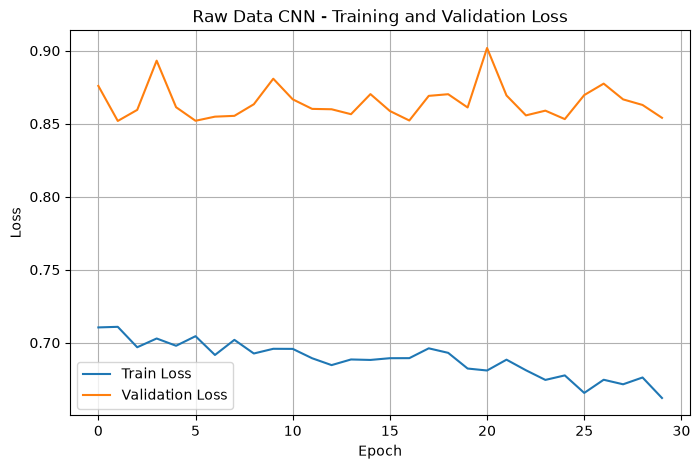

In [175]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Raw Data CNN - Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

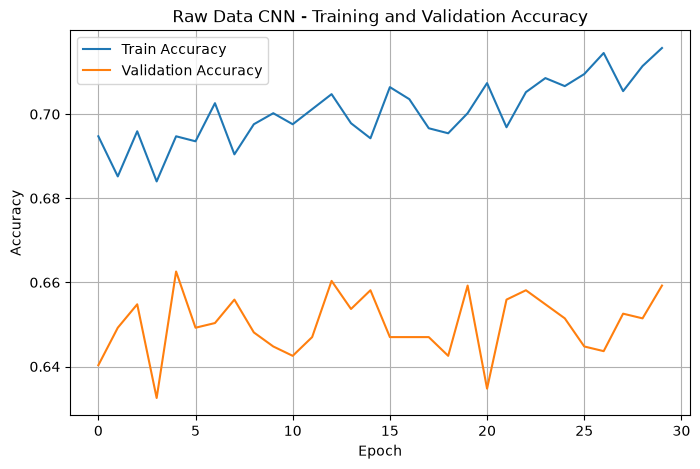

In [176]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Raw Data CNN - Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [177]:
print(model)

RawDataCNN(
  (features): Sequential(
    (0): Conv1d(6, 24, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(24, 24, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(24, 24, kernel_size=(5,), stride=(1,), padding=(2,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv1d(24, 24, kernel_size=(5,), stride=(1,), padding=(2,))
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.5, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=96, out_features=1368, bias=True)
    (2): ReLU()
    (3): Linear(in_features=1368, out_features=8, bias=True)
  )
)


In [178]:
class_names = [
    "asphalt",
    "cork",
    "grass",
    "gravel",
    "lab",
    "laminate_wood",
    "pebble",
    "sand"
]

In [179]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_val_predictions = []
all_val_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)

        outputs = model(X_batch)
        predictions = torch.argmax(outputs, dim=1)

        all_val_predictions.extend(predictions.cpu().numpy())
        all_val_labels.extend(y_batch.numpy())

all_val_predictions = np.array(all_val_predictions)
all_val_labels = np.array(all_val_labels)

print("Validation Classification Report:")
print(
    classification_report(
        all_val_labels,
        all_val_predictions,
        target_names=class_names,
        digits=4
    )
)

Validation Classification Report:
               precision    recall  f1-score   support

      asphalt     0.6867    0.4790    0.5644       119
         cork     0.5328    0.5909    0.5603       110
        grass     0.8737    0.7905    0.8300       105
       gravel     0.5745    0.4954    0.5320       109
          lab     0.5379    0.6121    0.5726       116
laminate_wood     0.5493    0.6724    0.6047       116
       pebble     0.6723    0.7339    0.7018       109
         sand     0.9640    0.9386    0.9511       114

     accuracy                         0.6626       898
    macro avg     0.6739    0.6641    0.6646       898
 weighted avg     0.6726    0.6626    0.6630       898



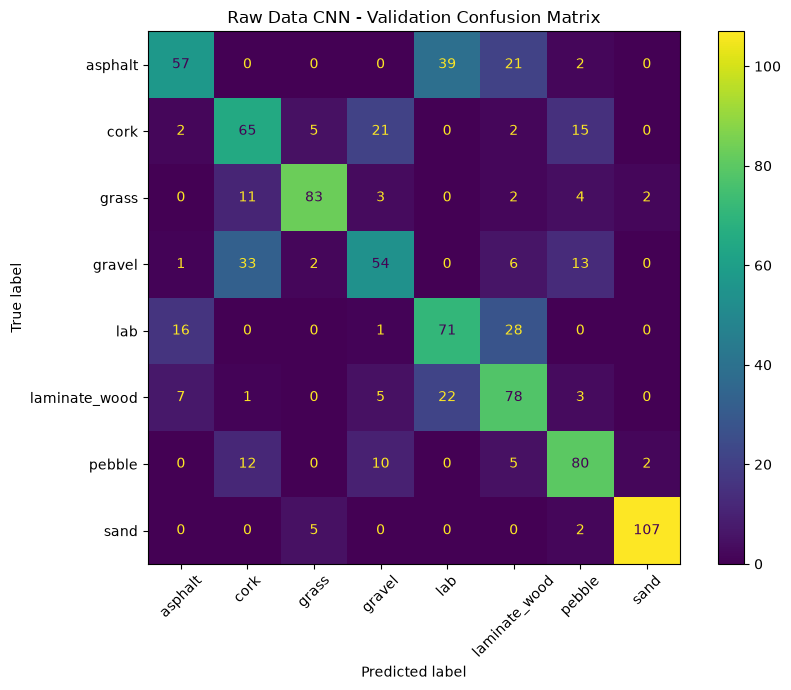

In [180]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    all_val_labels,
    all_val_predictions
)

plt.figure(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=plt.gca(),
    xticks_rotation=45
)

plt.title("Raw Data CNN - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [181]:
model.load_state_dict(best_model_state)   #TEST
model = model.to(device)
model.eval()

RawDataCNN(
  (features): Sequential(
    (0): Conv1d(6, 24, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(24, 24, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(24, 24, kernel_size=(5,), stride=(1,), padding=(2,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv1d(24, 24, kernel_size=(5,), stride=(1,), padding=(2,))
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.5, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=96, out_features=1368, bias=True)
    (2): ReLU()
    (3): Linear(in_features=1368, out_features=8, bias=True)
  )
)

In [182]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt

model.eval()

all_test_predictions = []
all_test_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        outputs = model(X_batch)
        predictions = torch.argmax(outputs, dim=1)

        all_test_predictions.extend(
            predictions.cpu().numpy()
        )
        all_test_labels.extend(
            y_batch.numpy()
        )

all_test_predictions = np.array(all_test_predictions)
all_test_labels = np.array(all_test_labels)

test_accuracy = accuracy_score(
    all_test_labels,
    all_test_predictions
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 0.6151
Test Accuracy: 61.51%


In [183]:
print("\nTest Classification Report:")

print(
    classification_report(
        all_test_labels,
        all_test_predictions,
        target_names=class_names,
        digits=4
    )
)


Test Classification Report:
               precision    recall  f1-score   support

      asphalt     0.5253    0.4333    0.4749       120
         cork     0.5225    0.5273    0.5249       110
        grass     0.8750    0.7333    0.7979       105
       gravel     0.4324    0.4404    0.4364       109
          lab     0.5203    0.5470    0.5333       117
laminate_wood     0.5282    0.6466    0.5814       116
       pebble     0.6195    0.6481    0.6335       108
         sand     0.9732    0.9561    0.9646       114

     accuracy                         0.6151       899
    macro avg     0.6245    0.6165    0.6184       899
 weighted avg     0.6224    0.6151    0.6166       899



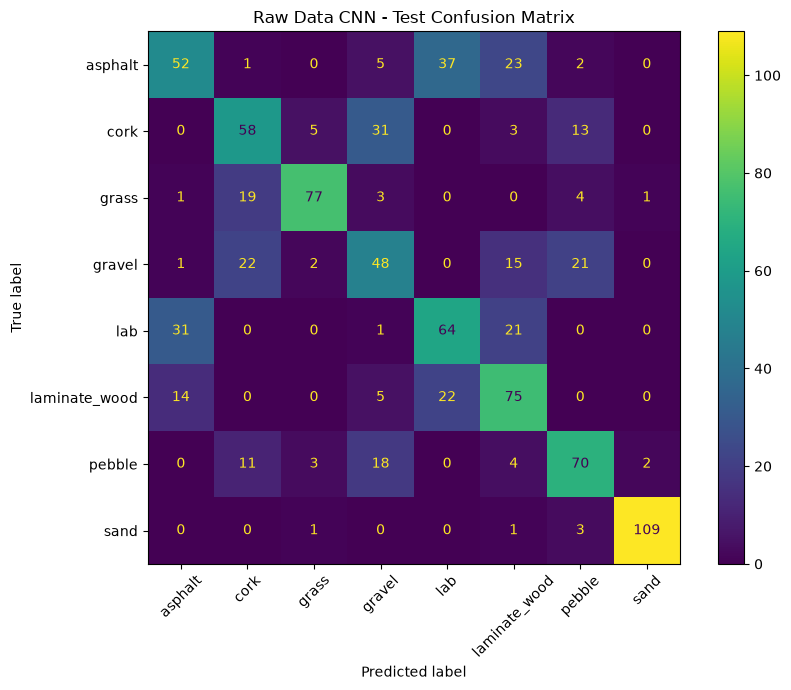

In [184]:
cm_test = confusion_matrix(
    all_test_labels,
    all_test_predictions
)

plt.figure(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=class_names
)

disp.plot(
    ax=plt.gca(),
    xticks_rotation=45
)

plt.title("Raw Data CNN - Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [185]:
#CNN_with_features

import random
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [186]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [187]:
X_features_train_tensor = torch.tensor(
    X_features_train,
    dtype=torch.float32
)

X_features_val_tensor = torch.tensor(
    X_features_val,
    dtype=torch.float32
)

X_features_test_tensor = torch.tensor(
    X_features_test,
    dtype=torch.float32
)

print("Train features:", X_features_train_tensor.shape)
print("Val features:", X_features_val_tensor.shape)
print("Test features:", X_features_test_tensor.shape)

Train features: torch.Size([4193, 33])
Val features: torch.Size([898, 33])
Test features: torch.Size([899, 33])


In [188]:
train_dataset = TensorDataset(
    X_train_tensor,
    X_features_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    X_features_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    X_features_test_tensor,
    y_test_tensor
)

In [189]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [190]:
class RawDataWithFeaturesCNN(nn.Module):

    def __init__(self, num_classes=8, num_features=33):
        super().__init__()

        self.conv1 = nn.Conv2d(
            6,
            24,
            kernel_size=(1, 5),
            stride=1,
            padding=(0, 1)
        )

        self.conv2 = nn.Conv2d(
            24,
            24,
            kernel_size=(1, 5),
            stride=1,
            padding=(0, 1)
        )

        self.conv3 = nn.Conv2d(
            24,
            24,
            kernel_size=(1, 5),
            stride=1,
            padding=(0, 1)
        )

        self.conv4 = nn.Conv2d(
            24,
            24,
            kernel_size=(1, 5),
            stride=1,
            padding=(0, 1)
        )

        self.pool = nn.MaxPool2d(
            kernel_size=(1, 2),
            stride=1
        )

        self.dropout = nn.Dropout(p=0.5)

        # 1368 learned CNN features + 33 engineered features
        self.fc1 = nn.Linear(
            1368 + num_features,
            50
        )

        self.fc2 = nn.Linear(
            50,
            num_classes
        )

    def forward(self, x, features):

        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = torch.relu(self.conv3(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = torch.relu(self.conv4(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = x.view(x.size(0), -1)

        # Concatenate learned CNN features + 33 engineered features
        x = torch.cat((x, features), dim=1)

        x = torch.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [192]:
model = RawDataWithFeaturesCNN(
    num_classes=8,
    num_features=33
).to(device)

sample_x, sample_features, sample_y = next(iter(train_loader))

sample_x = sample_x.unsqueeze(2).to(device)
sample_features = sample_features.to(device)

print("Tactile input:", sample_x.shape)
print("Features:", sample_features.shape)

with torch.no_grad():
    output = model(sample_x, sample_features)

print("Model output:", output.shape)

Tactile input: torch.Size([64, 6, 1, 69])
Features: torch.Size([64, 33])
Model output: torch.Size([64, 8])


In [193]:
print(model)

RawDataWithFeaturesCNN(
  (conv1): Conv2d(6, 24, kernel_size=(1, 5), stride=(1, 1), padding=(0, 1))
  (conv2): Conv2d(24, 24, kernel_size=(1, 5), stride=(1, 1), padding=(0, 1))
  (conv3): Conv2d(24, 24, kernel_size=(1, 5), stride=(1, 1), padding=(0, 1))
  (conv4): Conv2d(24, 24, kernel_size=(1, 5), stride=(1, 1), padding=(0, 1))
  (pool): MaxPool2d(kernel_size=(1, 2), stride=1, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=1401, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=8, bias=True)
)


In [194]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [195]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, features_batch, y_batch in loader:
        X_batch = X_batch.unsqueeze(2).to(device)
        features_batch = features_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch, features_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y_batch.size(0)

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [196]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, features_batch, y_batch in loader:
            X_batch = X_batch.unsqueeze(2).to(device)
            features_batch = features_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch, features_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * y_batch.size(0)

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [197]:
torch.manual_seed(SEED)

model = RawDataWithFeaturesCNN(
    num_classes=8,
    num_features=33
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

num_epochs = 60

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0
best_epoch = 0
best_model_state = None

for epoch in range(num_epochs):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [01/60] | Train Loss: 20.6982 | Train Acc: 0.1603 | Val Loss: 10.9934 | Val Acc: 0.2038
Epoch [02/60] | Train Loss: 9.1205 | Train Acc: 0.2132 | Val Loss: 7.4617 | Val Acc: 0.2728
Epoch [03/60] | Train Loss: 6.4324 | Train Acc: 0.2662 | Val Loss: 5.9179 | Val Acc: 0.2739
Epoch [04/60] | Train Loss: 4.8406 | Train Acc: 0.2988 | Val Loss: 4.3329 | Val Acc: 0.3096
Epoch [05/60] | Train Loss: 3.7773 | Train Acc: 0.3341 | Val Loss: 3.7890 | Val Acc: 0.3441
Epoch [06/60] | Train Loss: 3.1435 | Train Acc: 0.3565 | Val Loss: 3.3921 | Val Acc: 0.3563
Epoch [07/60] | Train Loss: 2.7581 | Train Acc: 0.3823 | Val Loss: 3.0945 | Val Acc: 0.3864
Epoch [08/60] | Train Loss: 2.4896 | Train Acc: 0.4038 | Val Loss: 2.9807 | Val Acc: 0.3697
Epoch [09/60] | Train Loss: 2.3150 | Train Acc: 0.4121 | Val Loss: 2.8813 | Val Acc: 0.3586
Epoch [10/60] | Train Loss: 2.1724 | Train Acc: 0.4183 | Val Loss: 2.4038 | Val Acc: 0.4031
Epoch [11/60] | Train Loss: 2.0481 | Train Acc: 0.4286 | Val Loss: 2.6010 | Va

In [198]:
model.load_state_dict(best_model_state)
model = model.to(device)

print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best epoch: {best_epoch}")

Best validation accuracy: 0.5223
Best epoch: 58
